# Exploratory Data Analysis for INX Future Inc Employee Performance

This notebook performs exploratory data analysis to understand employee
performance trends, department-wise variations, and relationships between
employee attributes and performance ratings. The insights generated here
will support feature selection and model building.


## 1. Import Required Libraries

Matplotlib & Seaborn are used for visual analysis

Visuals help uncover hidden patterns in employee behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Load Processed Dataset

In [2]:
df = pd.read_csv(r"C:\Users\madha\Desktop\Employee Performance Analysis\data\processed\employee_performance_processed.csv")
df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,ExperienceRatio,PromotionGap
0,32,1,2,2,5,13,2,10,3,4,...,2,2,10,7,0,8,0,3,0.636364,0.000000
1,47,1,2,2,5,13,2,14,4,4,...,2,3,7,7,1,7,0,3,0.333333,0.125000
2,40,1,1,1,5,13,1,5,4,4,...,2,3,18,13,1,12,0,4,0.619048,0.052632
3,41,1,0,0,3,8,2,10,4,2,...,2,2,21,6,12,6,0,3,0.250000,0.545455
4,60,1,2,2,5,13,2,16,4,1,...,1,3,2,2,2,2,0,3,0.181818,0.666667


## 3. Target Variable Distribution (Performance Rating)

In [3]:
df['PerformanceRating'].value_counts().sort_index()

PerformanceRating
2    194
3    874
4    132
Name: count, dtype: int64

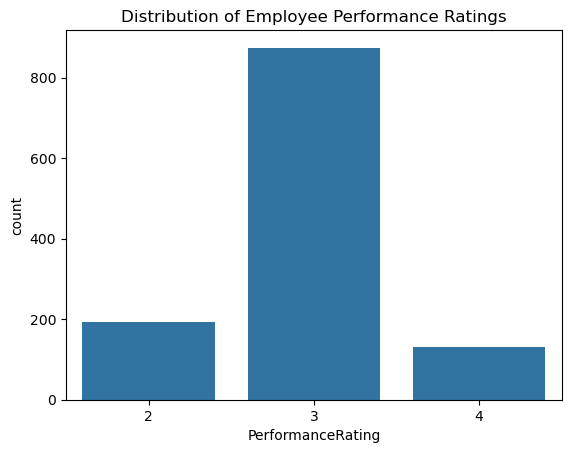

In [4]:
sns.countplot(x='PerformanceRating', data=df)
plt.title("Distribution of Employee Performance Ratings")
plt.show()

## 4. Department-wise Performance Analysis

Certain departments consistently outperform others

Indicates department-specific management or workload issues

In [5]:
dept_perf = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)
dept_perf

EmpDepartment
1    3.085873
0    3.050000
3    2.925926
4    2.921283
5    2.860590
2    2.775510
Name: PerformanceRating, dtype: float64

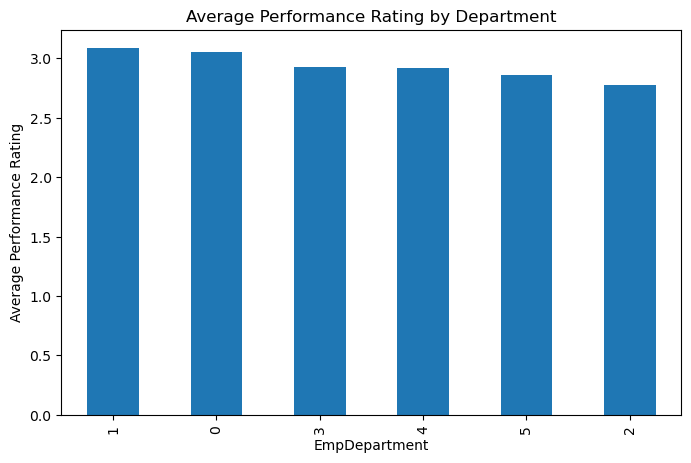

In [6]:
dept_perf.plot(kind='bar', figsize=(8,5))
plt.title("Average Performance Rating by Department")
plt.ylabel("Average Performance Rating")
plt.show()

## 5. Correlation Analysis (Feature Relationship Study)

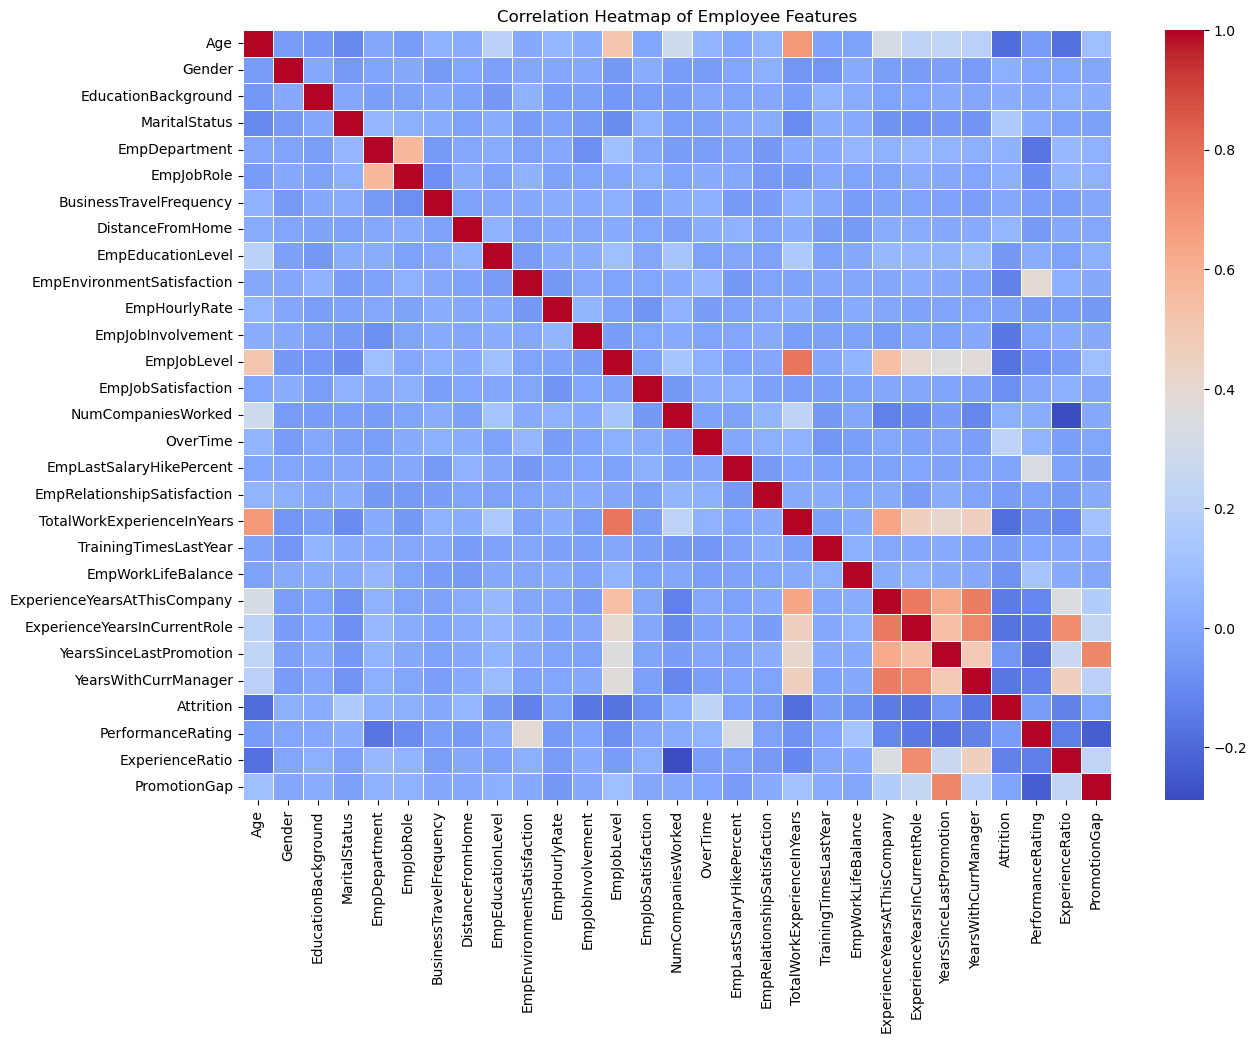

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Employee Features")
plt.show()

### Feature Selection Summary

Feature selection was guided by exploratory analysis, correlation study, and
ensemble model feature importance. Employee job satisfaction, work-life balance,
experience-related attributes, and promotion gap were identified as the most
influential features affecting performance. Feature engineering was applied to
capture career stagnation and progression indicators while preserving business
interpretability.


## 6. Key Feature vs Performance Analysis

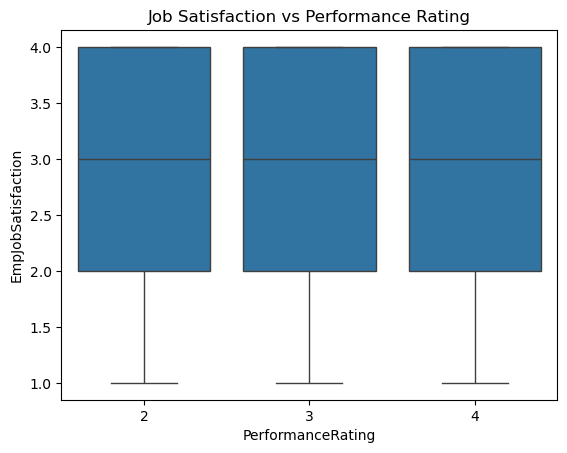

In [8]:
#Job Satisfaction vs Performance
sns.boxplot(x='PerformanceRating', y='EmpJobSatisfaction', data=df)
plt.title("Job Satisfaction vs Performance Rating")
plt.show()

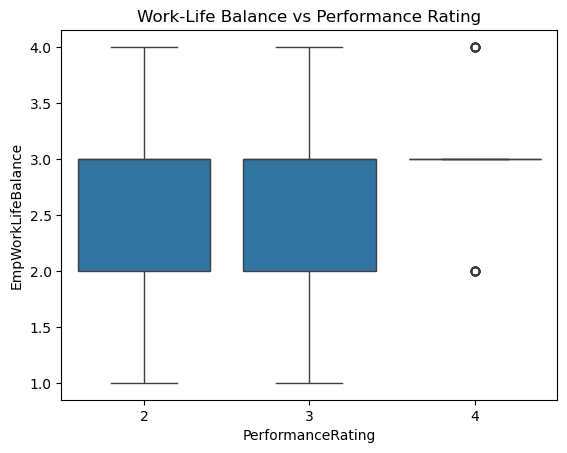

In [9]:
#Work-Life Balance vs Performance
sns.boxplot(x='PerformanceRating', y='EmpWorkLifeBalance', data=df)
plt.title("Work-Life Balance vs Performance Rating")
plt.show()

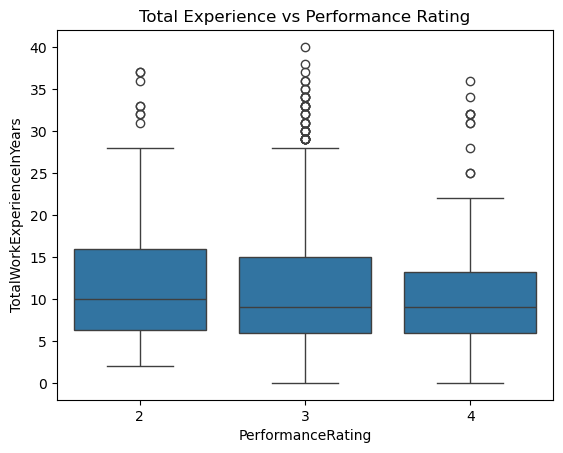

In [10]:
#Experience vs Performance
sns.boxplot(x='PerformanceRating', y='TotalWorkExperienceInYears', data=df)
plt.title("Total Experience vs Performance Rating")
plt.show()

### 7. Preliminary Feature Importance Candidates

(This supports Feature Selection section)

From EDA, strong candidates:

     1.EmpJobSatisfaction

     2.EmpWorkLifeBalance

     3.TotalWorkExperienceInYears

     4.YearsSinceLastPromotion

     5.TrainingTimesLastYear

### Key Insights from Exploratory Analysis

1. Employee performance varies significantly across departments.
2. Job satisfaction and work-life balance strongly influence performance.
3. Experience contributes positively but plateaus after a certain level.
4. Recent promotions and training are associated with higher performance ratings.

These insights will guide feature selection and machine learning model development.
